In [1]:
import numpy as np
import stim

from qsnow.interface import *
from qsnow.visualize import *

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf)  # type: ignore

import plotly.io as pio

pio.renderers.default = "png"

%load_ext autoreload
%aimport qsnow.interface.chip
%aimport qsnow.interface.models
%aimport qsnow.visualize.visualize
%autoreload 2

## Basic Chip Demo

Creating a basic l=5 x h=5 chip results in an underlying grid structure ranging from (0,0) to (2l, 2h). The chip is in a checkerboard style, where valid (x, y) coords have the property of x%2 == y%2. The chip can be visualized by using `chip.show()`

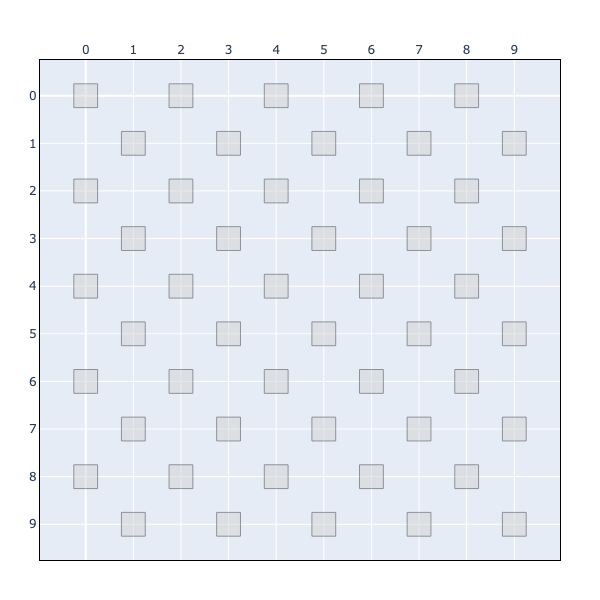

In [2]:
chip = Chip(5, 5)
chip.show()

In [3]:
chip.loc((0, 0)).status = Status.LOGICAL
chip.loc((5, 5)).status = Status.ANCILLA
print(chip.loc((0, 0)))
print(chip.loc((5, 5)))

Qubit(loc=(0, 0), status=Status.LOGICAL, type=CSSType.UNASSIGNED, noise=NoiseProfile(p=0.0))
Qubit(loc=(5, 5), status=Status.ANCILLA, type=CSSType.UNASSIGNED, noise=NoiseProfile(p=0.0))


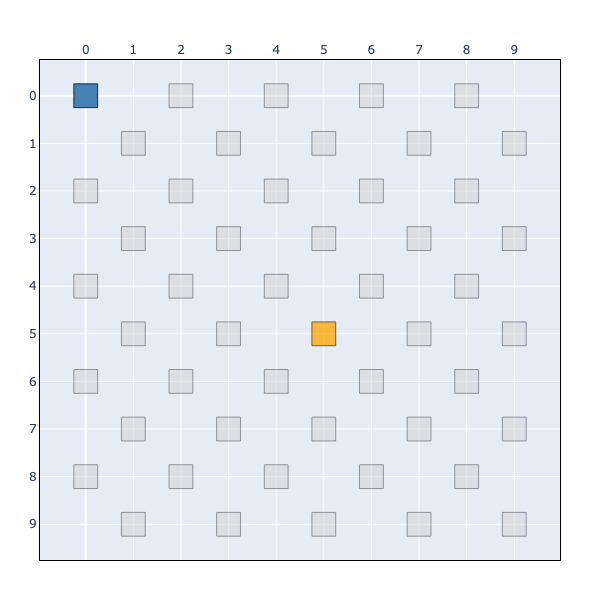

In [4]:
chip.show(style=default_style)

In [5]:
chip.generate_random_noise()
chip.loc((2, 2)).noise.p = 0.06
print(chip.loc((2, 2)))
print(chip.noise_map)

Qubit(loc=(2, 2), status=Status.INACTIVE, type=CSSType.UNASSIGNED, noise=NoiseProfile(p=0.06))
{(0, 0): NoiseProfile(p=0.04342), (0, 2): NoiseProfile(p=0.02676), (0, 4): NoiseProfile(p=0.01155), (0, 6): NoiseProfile(p=0.03312), (0, 8): NoiseProfile(p=0.01755), (1, 1): NoiseProfile(p=0.04394), (1, 3): NoiseProfile(p=0.01167), (1, 5): NoiseProfile(p=0.02962), (1, 7): NoiseProfile(p=0.04401), (1, 9): NoiseProfile(p=0.03922), (2, 0): NoiseProfile(p=0.01739), (2, 2): NoiseProfile(p=0.06), (2, 4): NoiseProfile(p=0.02276), (2, 6): NoiseProfile(p=0.03345), (2, 8): NoiseProfile(p=0.02286), (3, 1): NoiseProfile(p=0.02704), (3, 3): NoiseProfile(p=0.01783), (3, 5): NoiseProfile(p=0.0226), (3, 7): NoiseProfile(p=0.01858), (3, 9): NoiseProfile(p=0.03516), (4, 0): NoiseProfile(p=0.0309), (4, 2): NoiseProfile(p=0.04976), (4, 4): NoiseProfile(p=0.04669), (4, 6): NoiseProfile(p=0.01535), (4, 8): NoiseProfile(p=0.03366), (5, 1): NoiseProfile(p=0.01191), (5, 3): NoiseProfile(p=0.03936), (5, 5): NoiseProfi

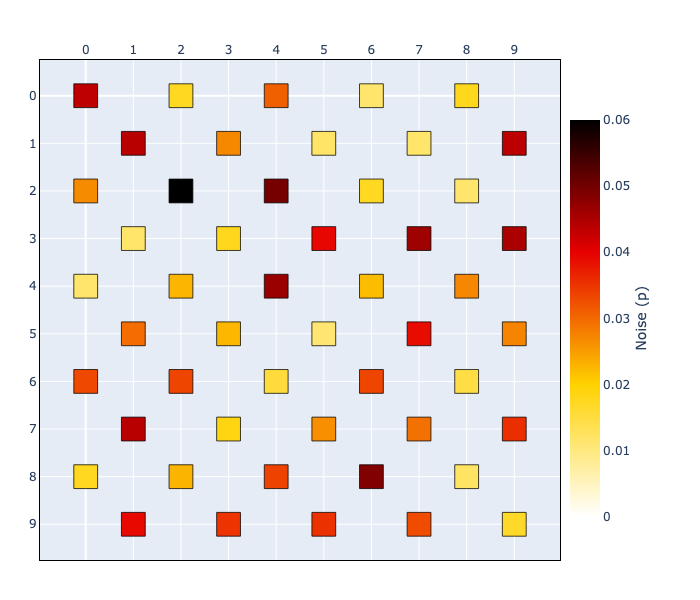

In [6]:
chip.show(style=noise_heatmap_style(chip, limits=(0.0, 0.06)))

## Logical Tile Placement and Shifts

Chips are a workspace for tiles, that represent logical qubits created from STIM circuits. To create a tile, provide a STIM circuit. The size and qubit coordinates are automatically pulled from the file. Once a chip has been instantiated, you can add tiles for a given coordinate, which represents the upper leftmost qubit of the tile. Any shifts or reorigins of the tiles uses the upper leftmost qubit as the reference point. Any shifts to the tile will automatically sync the coordinate grid of the underlying circuit and thus when circuits are compiled on a chip, qSNOW maps attributes of the chip's qubits automatically to the circuit, which can then be exported and sampled via Sinter.

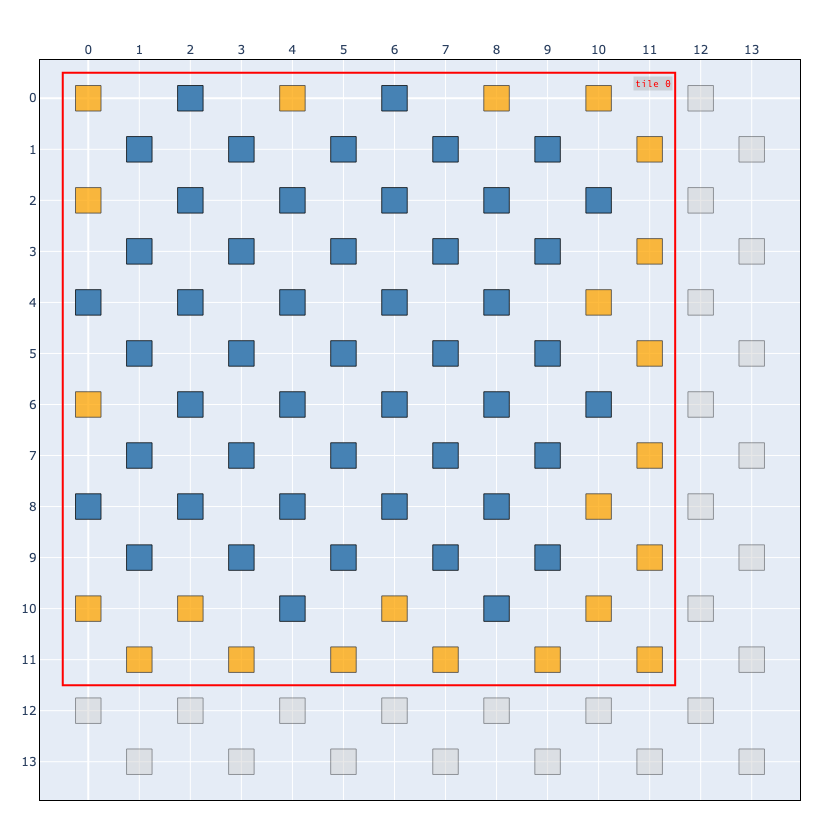

In [7]:
chip = Chip(7, 7)
tile = LogicalTile(
    stim.Circuit.generated(
        code_task="surface_code:rotated_memory_z", distance=5, rounds=3
    ),
    (0, 0),
)
chip.add_tile(tile, loc=(0, 0))
chip.generate_random_noise()
chip.show()

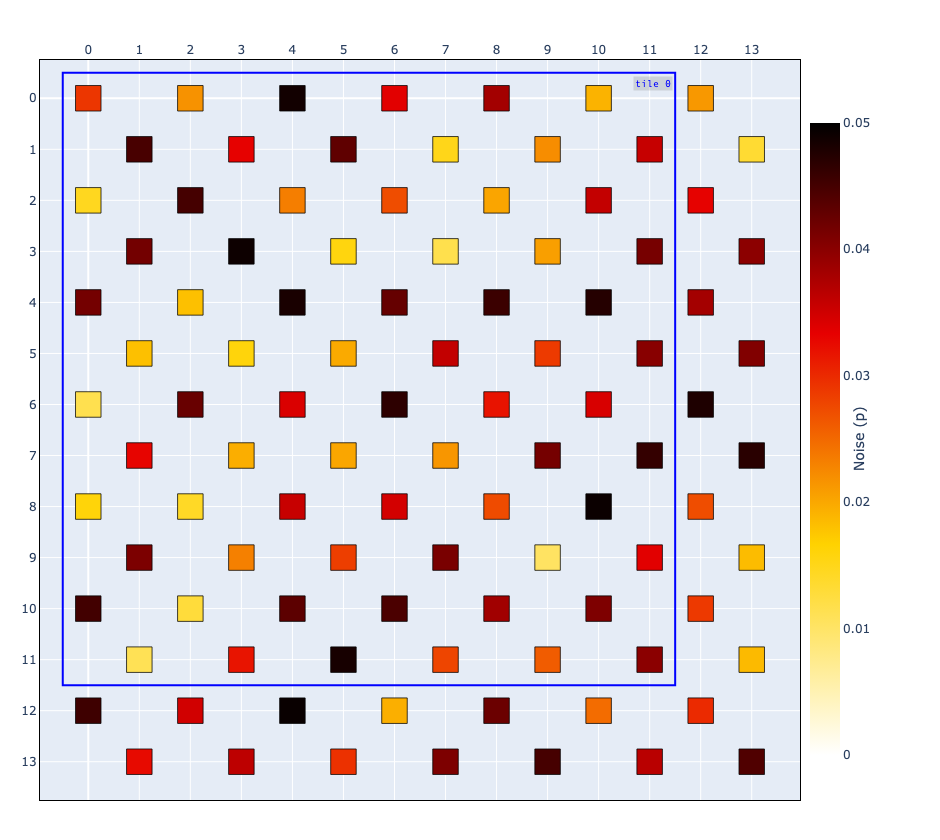

In [8]:
chip.show(style=noise_heatmap_style(chip, limits=(0.0, 0.05)))

In [9]:
chip.tiles[0].qubits

[Qubit(loc=(2, 0), status=Status.LOGICAL, type=CSSType.UNASSIGNED, noise=NoiseProfile(p=0.02174)),
 Qubit(loc=(0, 0), status=Status.ANCILLA, type=CSSType.UNASSIGNED, noise=NoiseProfile(p=0.02908)),
 Qubit(loc=(3, 1), status=Status.LOGICAL, type=CSSType.UNASSIGNED, noise=NoiseProfile(p=0.03325)),
 Qubit(loc=(1, 1), status=Status.LOGICAL, type=CSSType.UNASSIGNED, noise=NoiseProfile(p=0.04477)),
 Qubit(loc=(0, 2), status=Status.ANCILLA, type=CSSType.UNASSIGNED, noise=NoiseProfile(p=0.01464)),
 Qubit(loc=(2, 2), status=Status.LOGICAL, type=CSSType.UNASSIGNED, noise=NoiseProfile(p=0.04497)),
 Qubit(loc=(3, 3), status=Status.LOGICAL, type=CSSType.UNASSIGNED, noise=NoiseProfile(p=0.04907)),
 Qubit(loc=(1, 3), status=Status.LOGICAL, type=CSSType.UNASSIGNED, noise=NoiseProfile(p=0.0417)),
 Qubit(loc=(0, 4), status=Status.LOGICAL, type=CSSType.UNASSIGNED, noise=NoiseProfile(p=0.0416)),
 Qubit(loc=(2, 4), status=Status.LOGICAL, type=CSSType.UNASSIGNED, noise=NoiseProfile(p=0.01809)),
 Qubit(loc=(

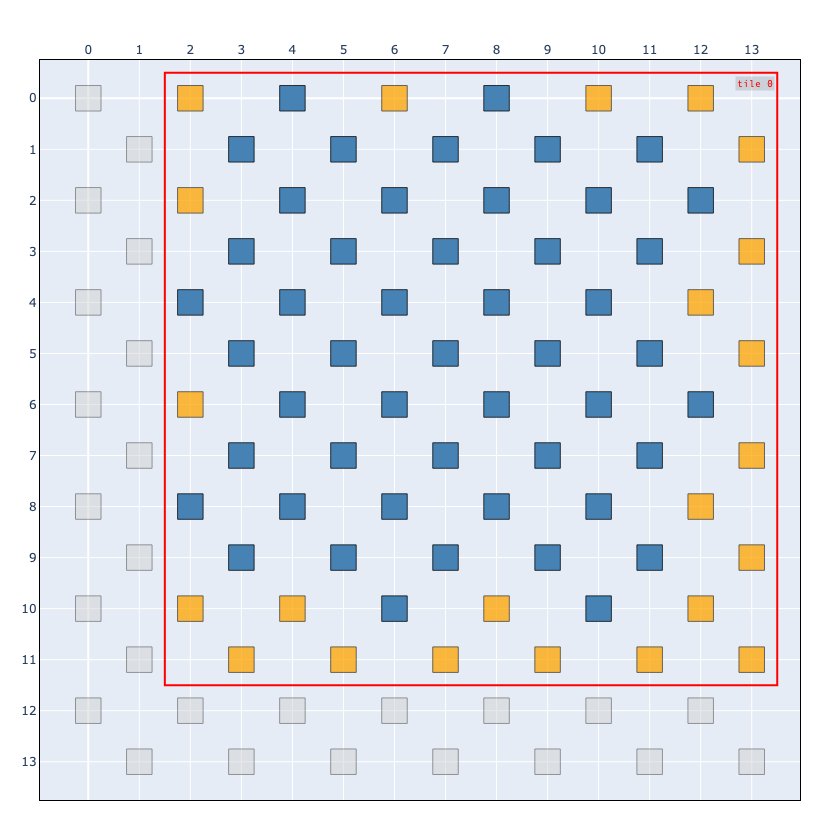

(2.0, 0.0)


In [10]:
chip.tiles[0].shift_to((2, 0))
chip.show()
print(chip.tiles[0].origin)

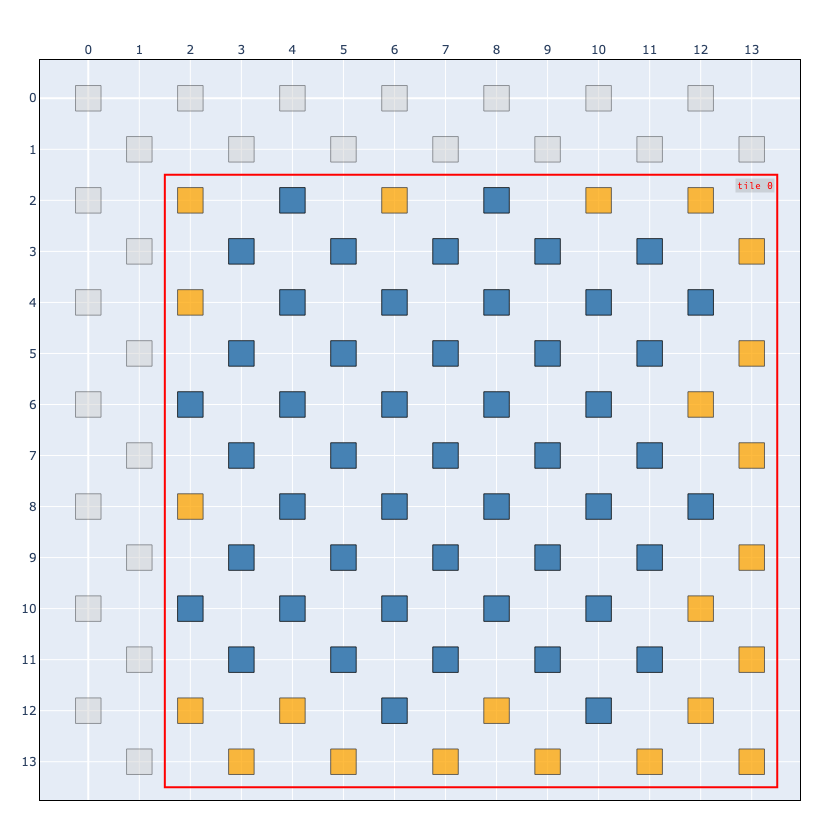

(2.0, 2.0)


In [11]:
chip.tiles[0].shift_by(0, 2)
chip.show()
print(chip.tiles[0].origin)

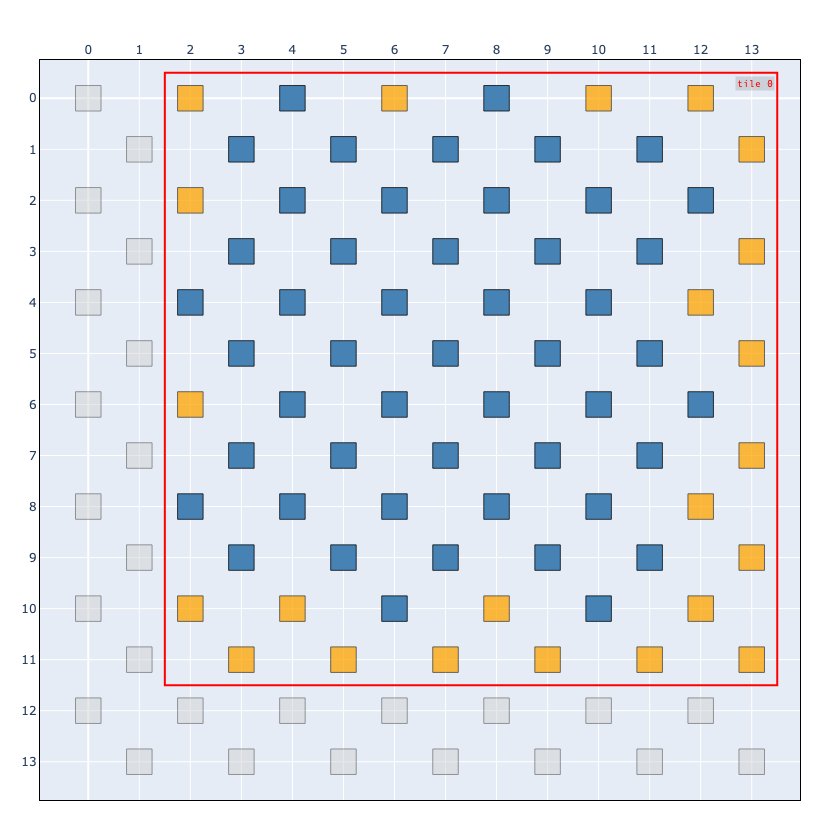

(2.0, 0.0)


In [12]:
chip.tiles[0].shift_by(0, -2)
chip.show()
print(chip.tiles[0].origin)

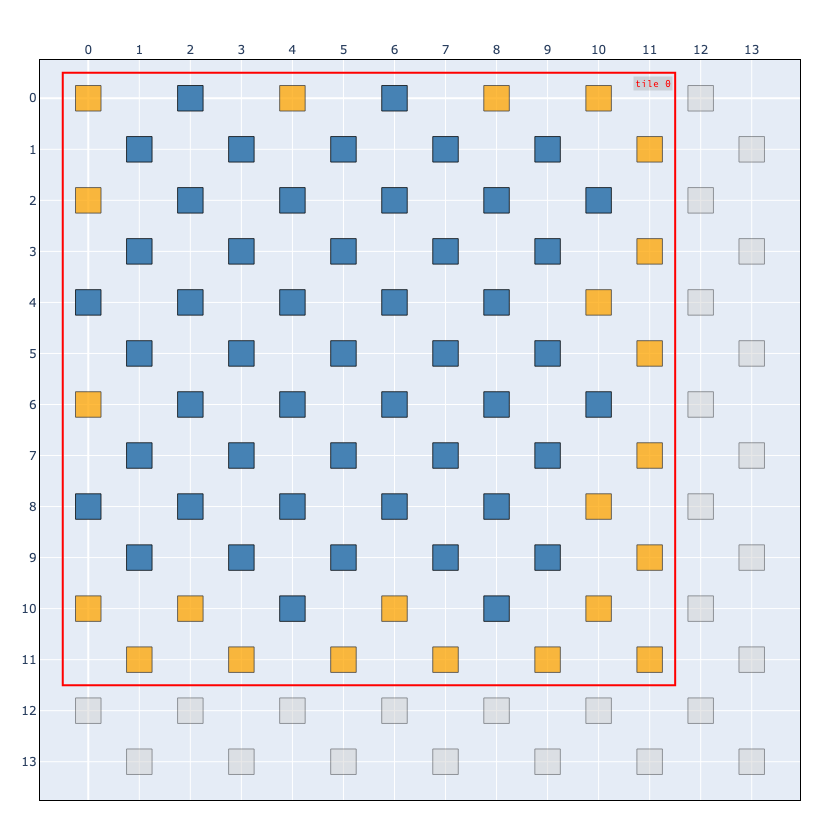

(0.0, 0.0)


In [13]:
chip.tiles[0].shift_by(-2, 0)
chip.show()
print(chip.tiles[0].origin)

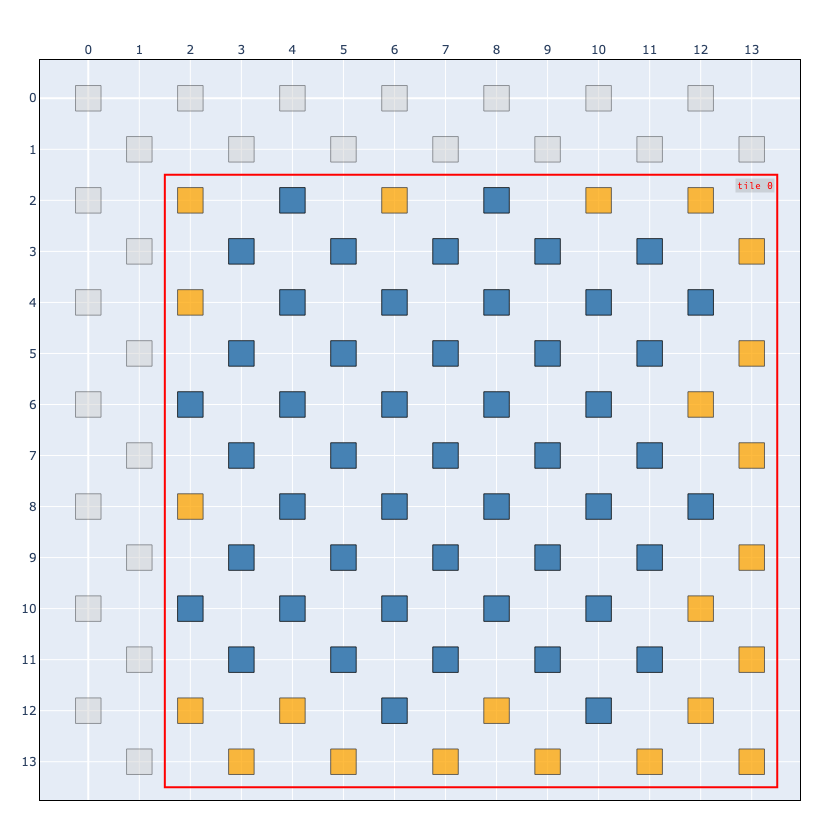

In [14]:
chip.tiles[0].shift_to((2, 2))
chip.show()

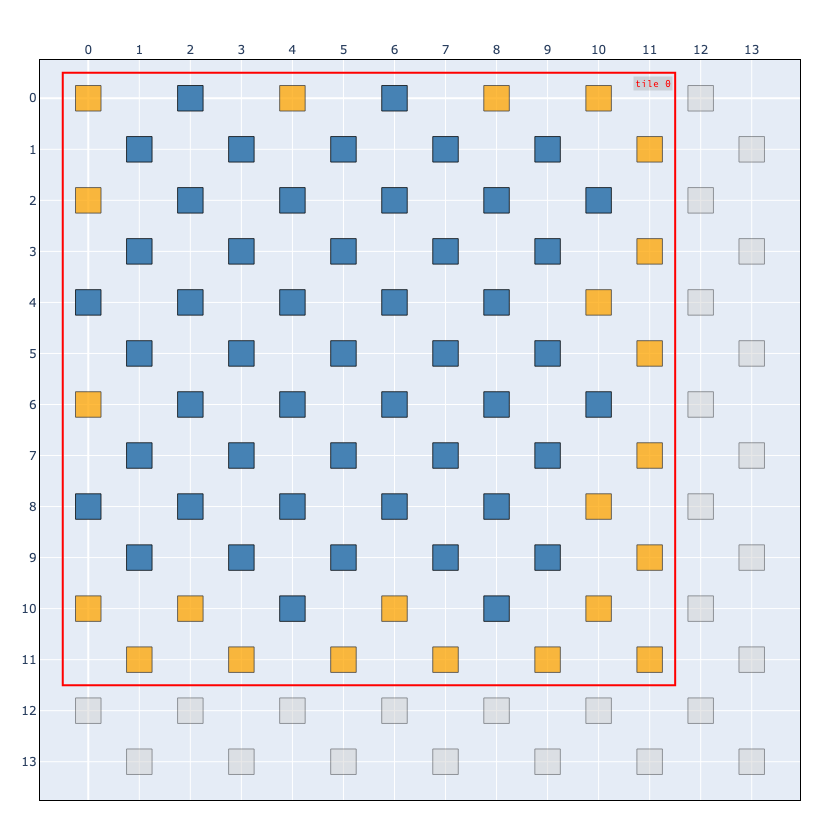

In [15]:
chip.tiles[0].shift_to((0, 0))
chip.show()

## Multi-Tile Demo

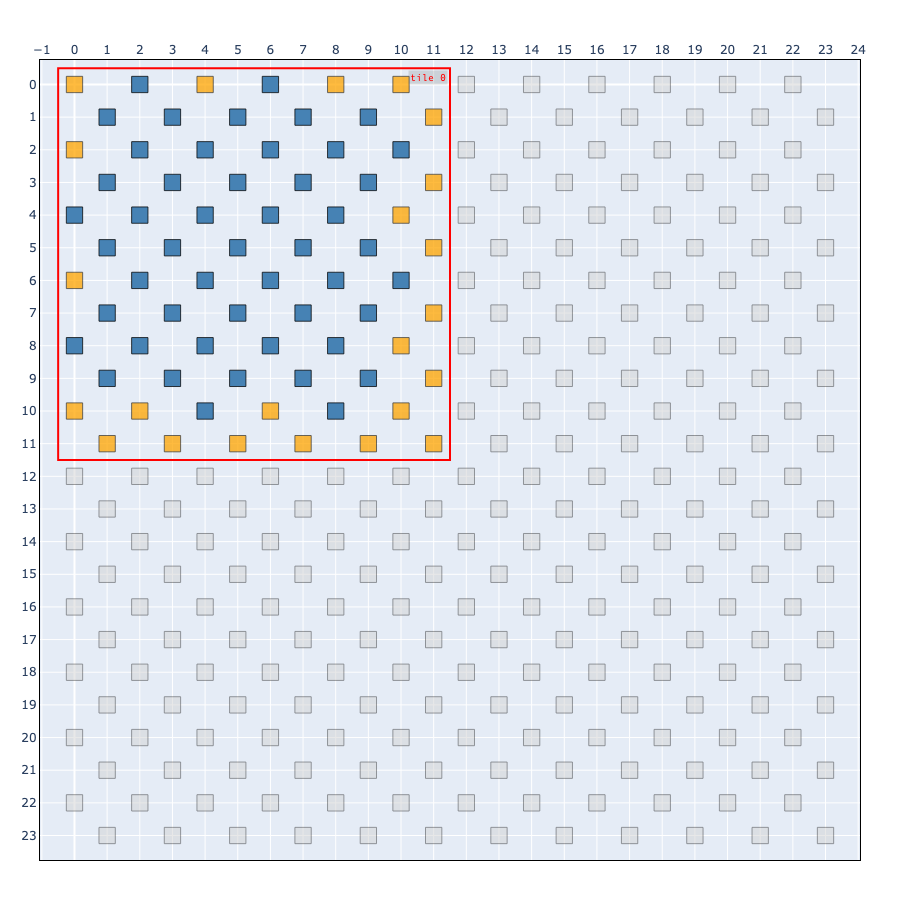

In [17]:
tile3 = LogicalTile(
    circuit=stim.Circuit.generated(
        code_task="surface_code:rotated_memory_z", distance=5, rounds=3
    ),
    spec=TileSpec(distance=5),
)
chip3 = Chip(12, 12)
chip3.generate_random_noise((0.0, 0.05))
chip3.add_tile(tile3, loc=(0, 0))
chip3.show()

In [18]:
chip3.add_tile(tile3.copy(), loc=(12, 0))
chip3.add_tile(tile3.copy(), loc=(0, 12))
chip3.add_tile(tile3.copy(), loc=(12, 12))

True

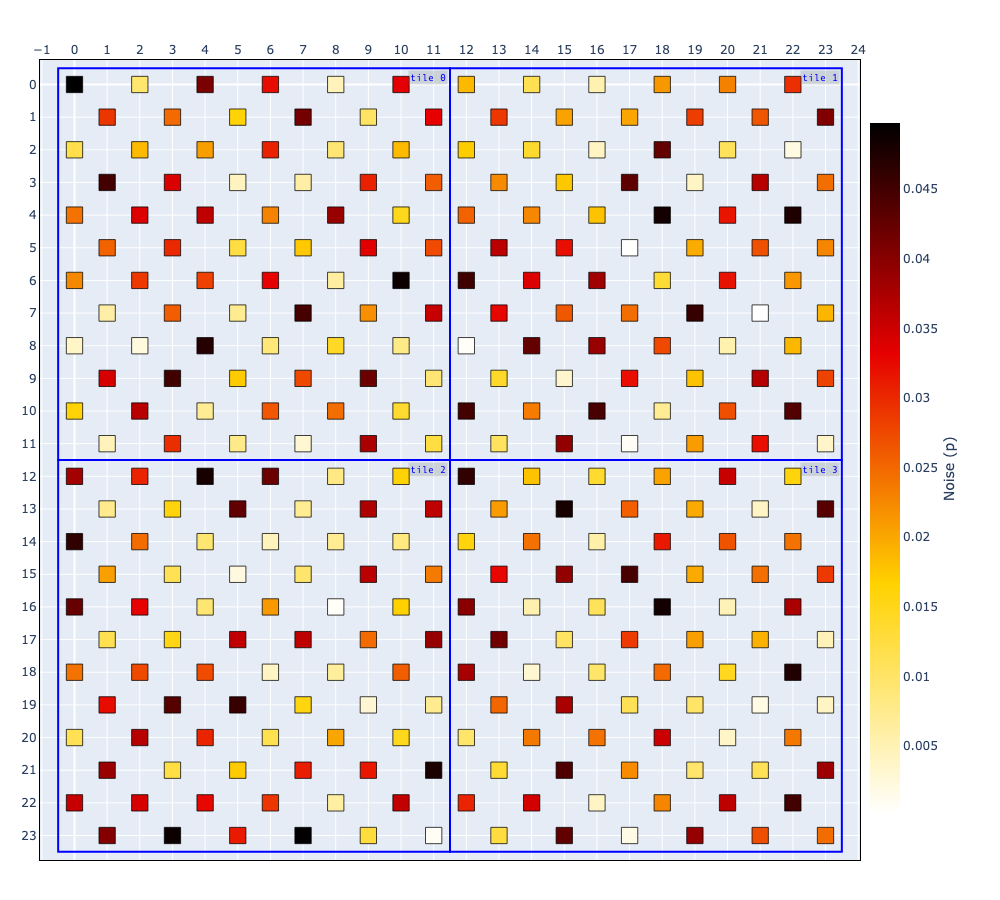

In [19]:
chip3.show(style=noise_heatmap_style(chip3))

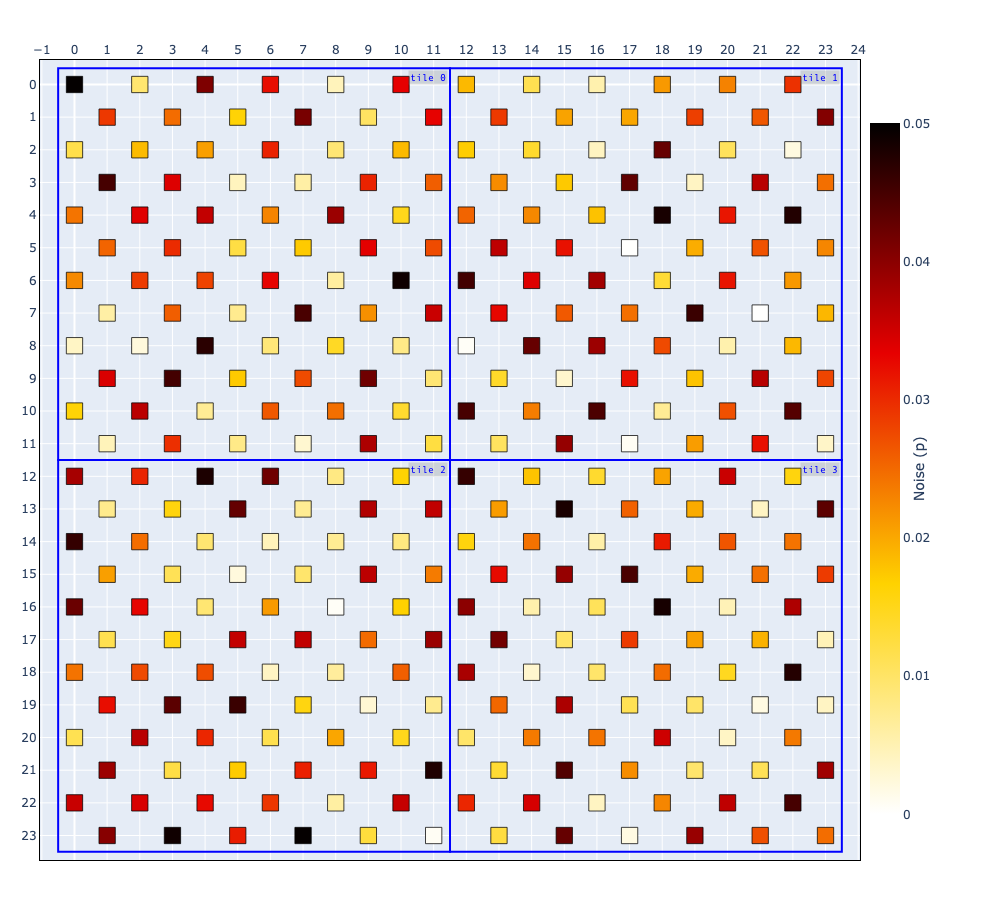

In [20]:
chip3.show(style=noise_heatmap_style(chip3, limits=(0.0, 0.05)))

## Multi Tile With Various Distances

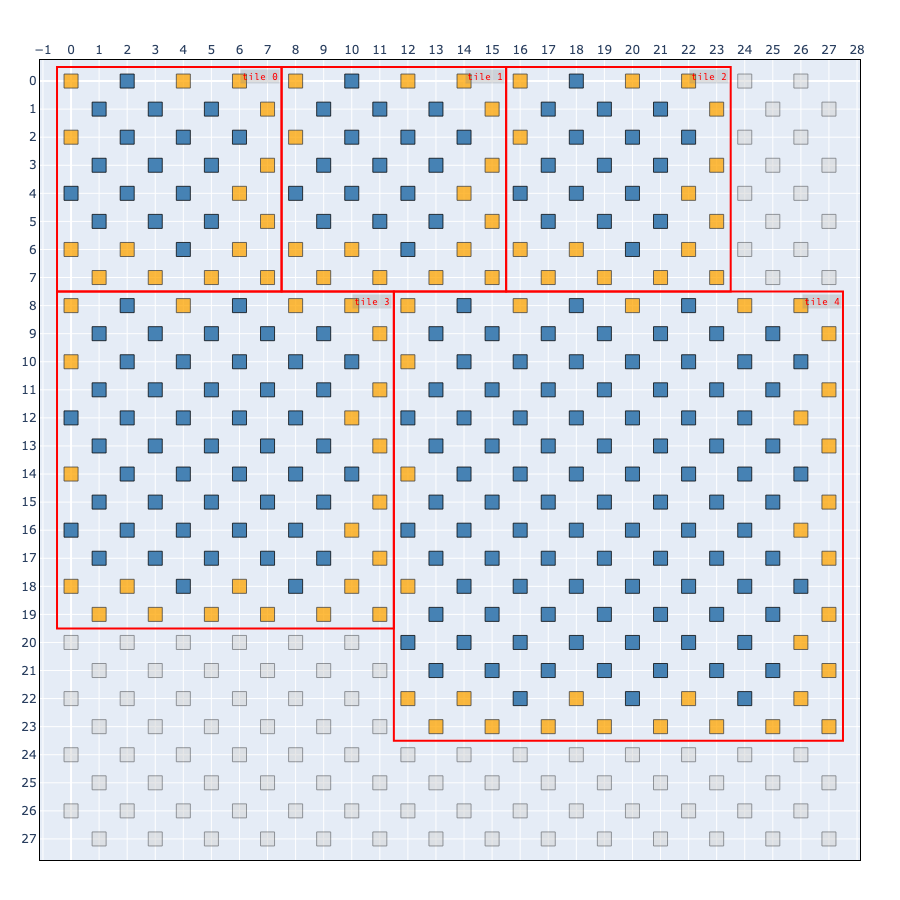

In [21]:
d3Tile = LogicalTile(
    circuit=stim.Circuit.generated(
        code_task="surface_code:rotated_memory_z", distance=3, rounds=3
    ),
    spec=TileSpec(distance=3),
)
d5Tile = LogicalTile(
    circuit=stim.Circuit.generated(
        code_task="surface_code:rotated_memory_z", distance=5, rounds=3
    ),
    spec=TileSpec(distance=5),
)
d7Tile = LogicalTile(
    circuit=stim.Circuit.generated(
        code_task="surface_code:rotated_memory_z", distance=7, rounds=3
    ),
    spec=TileSpec(distance=7),
)

chip4 = Chip(14, 14)
chip4.generate_random_noise((0.0, 0.05))
chip4.add_tile(d3Tile.copy(), loc=(0, 0))

chip4.add_tile(d3Tile.copy(), loc=(8, 0))
chip4.add_tile(d3Tile.copy(), loc=(16, 0))

chip4.add_tile(d5Tile.copy(), loc=(0, 8))

chip4.add_tile(d7Tile.copy(), loc=(12, 8))
chip4.show()

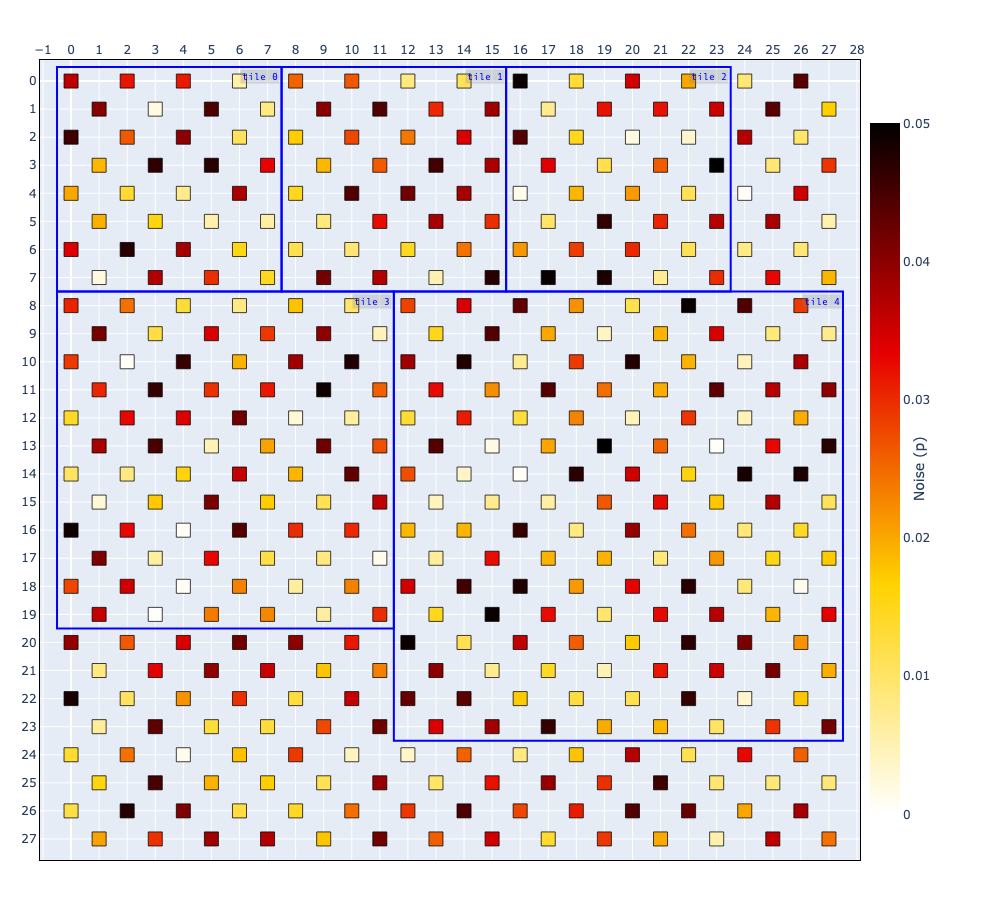

In [22]:
chip4.show(noise_heatmap_style(chip4, limits=(0.0, 0.05)))

In [23]:
chip4.tiles[0].circuit

stim.Circuit('''
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(2, 0) 2
    QUBIT_COORDS(3, 1) 3
    QUBIT_COORDS(5, 1) 5
    QUBIT_COORDS(1, 3) 8
    QUBIT_COORDS(2, 2) 9
    QUBIT_COORDS(3, 3) 10
    QUBIT_COORDS(4, 2) 11
    QUBIT_COORDS(5, 3) 12
    QUBIT_COORDS(6, 2) 13
    QUBIT_COORDS(0, 4) 14
    QUBIT_COORDS(1, 5) 15
    QUBIT_COORDS(2, 4) 16
    QUBIT_COORDS(3, 5) 17
    QUBIT_COORDS(4, 4) 18
    QUBIT_COORDS(5, 5) 19
    QUBIT_COORDS(4, 6) 25
    R 1 3 5 8 10 12 15 17 19 2 9 11 13 14 16 18 25
    TICK
    H 2 11 16 25
    TICK
    CX 2 3 16 17 11 12 15 14 10 9 19 18
    TICK
    CX 2 1 16 15 11 10 8 14 3 9 12 18
    TICK
    CX 16 10 11 5 25 19 8 9 17 18 12 13
    TICK
    CX 16 8 11 3 25 17 1 9 10 18 5 13
    TICK
    H 2 11 16 25
    TICK
    MR 2 9 11 13 14 16 18 25
    DETECTOR(0, 4, 0) rec[-4]
    DETECTOR(2, 2, 0) rec[-7]
    DETECTOR(4, 4, 0) rec[-2]
    DETECTOR(6, 2, 0) rec[-5]
    TICK
    H 2 11 16 25
    TICK
    CX 2 3 16 17 11 12 15 14 10 9 19 18
    TICK
    CX 2 1

In [24]:
stim.Circuit.generated(code_task="surface_code:rotated_memory_z", distance=3, rounds=3)

stim.Circuit('''
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(2, 0) 2
    QUBIT_COORDS(3, 1) 3
    QUBIT_COORDS(5, 1) 5
    QUBIT_COORDS(1, 3) 8
    QUBIT_COORDS(2, 2) 9
    QUBIT_COORDS(3, 3) 10
    QUBIT_COORDS(4, 2) 11
    QUBIT_COORDS(5, 3) 12
    QUBIT_COORDS(6, 2) 13
    QUBIT_COORDS(0, 4) 14
    QUBIT_COORDS(1, 5) 15
    QUBIT_COORDS(2, 4) 16
    QUBIT_COORDS(3, 5) 17
    QUBIT_COORDS(4, 4) 18
    QUBIT_COORDS(5, 5) 19
    QUBIT_COORDS(4, 6) 25
    R 1 3 5 8 10 12 15 17 19 2 9 11 13 14 16 18 25
    TICK
    H 2 11 16 25
    TICK
    CX 2 3 16 17 11 12 15 14 10 9 19 18
    TICK
    CX 2 1 16 15 11 10 8 14 3 9 12 18
    TICK
    CX 16 10 11 5 25 19 8 9 17 18 12 13
    TICK
    CX 16 8 11 3 25 17 1 9 10 18 5 13
    TICK
    H 2 11 16 25
    TICK
    MR 2 9 11 13 14 16 18 25
    DETECTOR(0, 4, 0) rec[-4]
    DETECTOR(2, 2, 0) rec[-7]
    DETECTOR(4, 4, 0) rec[-2]
    DETECTOR(6, 2, 0) rec[-5]
    REPEAT 2 {
        TICK
        H 2 11 16 25
        TICK
        CX 2 3 16 17 11 12 15 14

## Noise Rules and Surface Code Tiles

By default, `LogicalTiles` are code agnostic but are intended to be used with CSS codes, thus each qubit has an associated `CSSType` which is initially set to `UNASSIGNED`.
As of right now, the best way to implement a code formally is by wrapping a some sort of Stim circuit generator in a class extending `LogicalTile` and overriding `_init_tile_qubit_types()`, `_inject_circuit_noise`, and `copy()` (optional but helpful for quickly populating tiles). This way, the specific way that CSS types are determined and noise is injected can be code specific.

For reference, the `SCTile` is a rotated surface code tile that takes distance, rounds, and task type (i.e., mem-z or mem-x circuit) and determines the appropriate CSS qubit types based on the layout of a given RSC patch. [WIP] (While the noise rule setup is pretty extendable as is, I plan to connect the Ruleset to the chip so that this ruleset can essentially make a chip "reflect" some sort of hardware specific noise configuration)

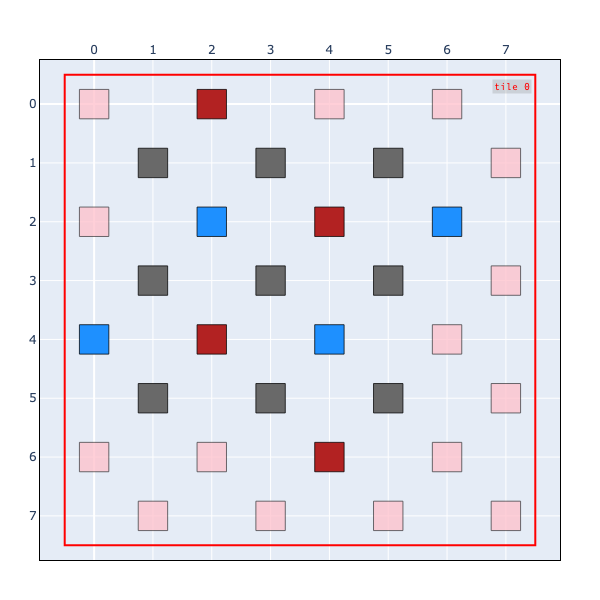

In [25]:
chip = Chip(4, 4)
tile = SCTile(distance=3, rounds=3, task="memory_z")
chip.add_tile(tile)
chip.show(style=css_style)

In [26]:
tile._ruleset

0:R:all_qubits
1:H:x_measures
2:CX:any
3:MR:all_measures
4:M:data

When `tile.circuit` is called on a tile that has been initialized to a chip, the circuit is injected with noise per the tiles `Ruleset` (currently within the noise injection function as an example for the moment) and returned. Additionally, any injected noise is tagged in the stim circuit with a summary of the triggering rule. Tags in stim are inconsequential and serve no functional purpose outside of allowing 3rd party tools, like this, to add additional layers of information directly within the Stim circuit for later reuse or informational purposes.

Reading a tag details what triggered this rule and what qubits the rules noise channel was injected on. They follow a somewhat *If this, then that* formula. For example:

Imagine that q1 is a measurement qubit and q2 is a data qubit. The tag for a rule that specified that after a `MR` operations that occurs on all `measure` qubits, we should apply a `X_ERROR` channel to all measurement qubits and a `DEPOLARIZE1` to all data qubits looks like the following

```
MR q1
X_ERROR[MR:all_measures -> X_ERROR:all_measures](<noise for q1>) q1
DEPOLARIZE1[MR:all_measures -> DEPOLARIZE1:data](<noise for q2>) q2
```

This is a big WIP atm and will be adapted to allow both spatial and temporal rules and more complex rule definitions.

In [27]:
chip.generate_gaussian_noise(mean=0.005, deviation=0.0006)
tile.circuit

stim.Circuit('''
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(2, 0) 2
    QUBIT_COORDS(3, 1) 3
    QUBIT_COORDS(5, 1) 5
    QUBIT_COORDS(1, 3) 8
    QUBIT_COORDS(2, 2) 9
    QUBIT_COORDS(3, 3) 10
    QUBIT_COORDS(4, 2) 11
    QUBIT_COORDS(5, 3) 12
    QUBIT_COORDS(6, 2) 13
    QUBIT_COORDS(0, 4) 14
    QUBIT_COORDS(1, 5) 15
    QUBIT_COORDS(2, 4) 16
    QUBIT_COORDS(3, 5) 17
    QUBIT_COORDS(4, 4) 18
    QUBIT_COORDS(5, 5) 19
    QUBIT_COORDS(4, 6) 25
    R 1 3 5 8 10 12 15 17 19 2 9 11 13 14 16 18 25
    X_ERROR[R:all_qubits -> X_ERROR:all_qubits](0.00344) 1
    X_ERROR[R:all_qubits -> X_ERROR:all_qubits](0.00503) 2
    X_ERROR[R:all_qubits -> X_ERROR:all_qubits](0.005) 3
    X_ERROR[R:all_qubits -> X_ERROR:all_qubits](0.0054) 5
    X_ERROR[R:all_qubits -> X_ERROR:all_qubits](0.00539) 8
    X_ERROR[R:all_qubits -> X_ERROR:all_qubits](0.00565) 9
    X_ERROR[R:all_qubits -> X_ERROR:all_qubits](0.00522) 10
    X_ERROR[R:all_qubits -> X_ERROR:all_qubits](0.0049) 11
    X_ERROR[R:all_qubits -

## Serialization and qSNOW flakes 


All qSNOW objects support exporting as .flake files, which is a serialized qSNOW configuration file containing all relevant attributes and information 
used to generate the qSNOW flake. Thus, the serialization library supports round-tripping (1:1 import-export) of `Chip`, `LogicalTile` 
(and code subclasses like `SCTile`), `Experiment`, etc. through the `.flake` JSON files, capturing everything needed for qSNOW to rebuild the object down the line. Any object can be serialized by calling `serialize.export_flake(<qSNOW obj>)`, which will save the qSNOW object at path specified by global data directory variable. 

```python
    from qsnow.helpers.serialize import export_json, import_json, import_latest

    export_flake(chip)                                                      # -> data/chips/chip_5x5_<timestamp>.flake
    export_flake(tile)                                                      # -> data/tiles/tile_rsc_memory_z_d3_<timestamp>.flake
    export_flake(experiment, label='exp1')                                  # -> data/experiment/
    chip = import_latest("chip")                                            # newest matching export
    chip = import_flake("data/chips/chip_5x5_2026-07-10_12-00-00.flake")    # 
    export_flake(chip, "somewhere/else.flake")                              # explicit path still works, but will not use default naming scheme
```

The default directory can be reconfigured by calling `serialize.set_data_dir` and providing a `Path` or `str` object:

```python
    from qsnow.helpers.serialize import get_data_dir, set_data_dir

    set_data_dir('/Users/WNavidson/flakes')                                 # move default path for flakes 
    export_flake(tile, label='processor_config_1')                          # -> /Users/WNavidson/flakes/tiles/tile_processor_config_1_<timestamp>.flake
    tile = import_latest("tile*config_1")                                   # matches to .flake exported above
```

While versioning is technically supported as is, the format_version 1.0 will likely change slightly before the full migration factory setup is fully consistently.